### Imports

In [2]:
import copy

# import shutil
# import torch
# import torchvision
import json
import os
import random
from collections import defaultdict, deque

# from logger import Logger
# from typing import Dict, List, Tuple
import gym_simplegrid
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# from torch.utils.tensorboard import SummaryWriter
import scipy
from buffer import ReplayBuffer
from gym_simplegrid import envs
from plot import plot_avg_true_Q, plot_metric
from utils import Logger


###  Create an  example env and print related info

In [214]:
import numpy as np

obstacle_map = [
    "000",
    "000",
    "000",
]
start_loc = (1, 1)
goal_loc = [(0, 0), (2, 2)]
map_name = "square"
map_str = np.asarray(obstacle_map, dtype="c")
print(map_str)
map_int = np.asarray(map_str, dtype=int)
print(map_int)

env = gym.make(
    "SimpleGrid-v0",
    obstacle_map=obstacle_map,
    # render_mode='human',
    max_episode_steps=300,
    render_mode=None,
)
print(env.observation_space.n)
obs, info = env.reset(options={"start_loc": start_loc, "goal_loc": goal_loc})
print(obs)
print(np.zeros(1))
print(env._max_episode_steps)

[[b'0' b'0' b'0']
 [b'0' b'0' b'0']
 [b'0' b'0' b'0']]
[[0 0 0]
 [0 0 0]
 [0 0 0]]
9
4
[0.]
300


### Define MDP

In [215]:
MOVES = {
    0: (-1, 0),  # UP
    1: (1, 0),  # DOWN
    2: (0, -1),  # LEFT
    3: (0, 1),  # RIGHT
    4: (0, 0),  # STAY
    5: (0, 0),
    6: (0, 0),
    7: (0, 0),
    8: (0, 0),
    9: (0, 0),
}


# [Load a custom map]
# obstacle_map = [
#     "0000000000000",
#     "0000000000000",
#     "0000000000000",
#     "1111000001111",
#     "0000000000000",
#     "0000000000000",
#     "0000000000000",
# ]
# start_loc = (6,1)
# goal_loc = [(0,10), (1,2), (6,10)]
# map_name = "2roomsBig_rwd0.1(-0.1,1)"

# obstacle_map = [
#     "0000000",
#     "0000000",
#     "0000000",
#     "1110111",
#     "0000000",
#     "0000000",
#     "0000000",
# ]

# start_loc = (3, 3)
# # goal_loc = [(0,3), (6,3), (1,1)]
# goal_loc = [(0, 3), (6, 3)]
# map_name = "2rooms_rwd0.1(-0.1,1)"
# env_name = "SimpleGrid-v0"


# obstacle_map = [
#         "000",
#         "000",
#     ]
# start_loc = (1,1)
# goal_loc = [(0,0), (1,2)]
# map_name = "2row"

# obstacle_map = [
#         "000",
#         "000",
#         "000",
#     ]
# start_loc = (1,1)
# goal_loc = [(0,0), (2,2)]
# map_name = "square"

# Create a obstacle map with 3x3 grid from paper Double Q-learning
obstacle_map = [
    "000",
    "000",
    "000",
]
start_loc = (2, 0)
goal_loc = [(0,2),]
map_name = "GridInDoubleQ"
env_name = "GridEnvFromDoubleQLearning-v0"

MDP = {
    "obstacle_map": obstacle_map,
    "start_loc": start_loc,
    "goal_loc": goal_loc,
    "map_name": map_name,
    "env_name": env_name,
    "MOVES": MOVES,
}

### Define Config

In [216]:
# 2-Room GridWorld
# config = {
#     # "temperature_start": 1.0, # for softmax explore, if set to not None, it will be used, overwriting eps
#     # "temperature_end": 0.01,
#     # "temperature_decay": 0.99995,
#     # "temperature": [1.0, 0.01, 0.99995], # [init, min, decay]
#     "eps": [0.5, 0.0, 0.99995], # use when "total_steps": 100000
#     # "eps": [0.5, 0.0, 0.9998], # [init, min, decay] like [0.5, 0.0, 0.99995] or "count_based"
#     # "eps": "count_based",
#     "alpha": [0.1, 0.00, 1.0], # [init, min, decay] like [0.1, 0.01, 1.0] or "count_based"
#     # "alpha": "count_based",
#     "gamma": 0.99,
#     "random_value_init": True,
#     "alpha_v": 0.1,
#     "alpha_q": 0.1,
#     "buffer_size": 1000,
#     "batch_size": 1,
#     "importance_sampling": 0.0,  # this will work as a threshold
#     "syncVQ": False,
#     "noisy_update": 0.0,
#     "eval_freq": 500,
#     # "eval_total_steps": 300,
#     "max_episode_steps": 300,
#     "total_steps": 100000,
#     "n_final_evals": 5,
#     "n_actions": len(MOVES),
# }

# Double Q-learning 3x3 GridWorld
config = {
    # "temperature_start": 1.0, # for softmax explore, if set to not None, it will be used, overwriting eps
    # "temperature_end": 0.01,
    # "temperature_decay": 0.99995,
    # "eps": [0.1, 0.0, 0.997], # [init, min, decay] like [0.5, 0.0, 0.99995] or "count_based"
    "eps": "count_based",
    # "temperature": [1.0, 0.01, 0.99995], # [init, min, decay]
    # "alpha": [0.1, 0.00, 0.9995], # [init, min, decay] like [0.1, 0.01, 1.0] or "count_based"
    "alpha": "count_based",
    "gamma": 0.95,
    "random_value_init": False,
    "alpha_v": 0.1,
    "alpha_q": 0.1,
    "buffer_size": 500,
    "batch_size": 1,
    "importance_sampling": 0.0,  # this will work as a threshold
    "syncVQ": False,
    "noisy_update": 0.0,
    "eval_freq": 50,
    "eval_total_steps": 100,
    "max_episode_steps": 100,
    "total_steps": 10000,
    "n_final_evals": 10,
    "n_actions": len(MOVES),
}



### Run experiment with different algos

In [217]:
from run import run_experiment

algo_names = ["Q-learning", "VQ-learning", "DoubleQ-learning", "SARSA", "ExpectedSARSA"]
# algo_names = ["Q-learning", "DoubleQ-learning"]
log_dirs = []
for algo_name in algo_names:
    config["algo_name"] = algo_name
    log_dir = run_experiment(MDP, config, n_repeat=20)
    # more hyperparameters to be set within run_experiment
    print(f"{algo_name} done!")
    print(log_dir)
    log_dirs.append(log_dir)

def remove_last_path_component(path):
    """Remove the last component from a path string."""
    components = path.split('/')
    return '/'.join(components[:-1])
parent_log_dir = remove_last_path_component(log_dirs[0])
print("parent_log_dir: ", parent_log_dir)

Q-learning done!
results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/Q-learning
VQ-learning done!
results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/VQ-learning
DoubleQ-learning done!
results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/DoubleQ-learning
SARSA done!
results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/SARSA
ExpectedSARSA done!
results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/ExpectedSARSA
parent_log_dir:  results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000


###  Load from raw log data

In [ ]:
# Manual replot from raw data
algo_names = ["Q-learning", "VQ-learning", "DoubleQ-learning", "SARSA", "ExpectedSARSA"]
parent_log_dir = '/Users/yuan/work/temp/DVQN_RL/gridworld/results/2rooms_rwd0.1(-0.1,1)/nA4_randinit1_Eps|[0.5, 0.0, 0.9998]|_Alpha|[0.1, 0.0, 1.0]|_Buff1000-1_noisyV0.0_repeat41_steps30000'
log_dirs = [os.path.join(parent_log_dir, algo_name) for algo_name in algo_names]

In [186]:

print(log_dirs)


['results/2rooms_rwd0.1(-0.1,1)/nA10_randinit1_Eps|[0.5, 0.0, 0.9998]|_Alpha|[0.1, 0.0, 1.0]|_Buff1-1_noisyV0.0_repeat30_steps100000/Q-learning', 'results/2rooms_rwd0.1(-0.1,1)/nA10_randinit1_Eps|[0.5, 0.0, 0.9998]|_Alpha|[0.1, 0.0, 1.0]|_Buff1-1_noisyV0.0_repeat30_steps100000/VQ-learning', 'results/2rooms_rwd0.1(-0.1,1)/nA10_randinit1_Eps|[0.5, 0.0, 0.9998]|_Alpha|[0.1, 0.0, 1.0]|_Buff1-1_noisyV0.0_repeat30_steps100000/DoubleQ-learning', 'results/2rooms_rwd0.1(-0.1,1)/nA10_randinit1_Eps|[0.5, 0.0, 0.9998]|_Alpha|[0.1, 0.0, 1.0]|_Buff1-1_noisyV0.0_repeat30_steps100000/SARSA', 'results/2rooms_rwd0.1(-0.1,1)/nA10_randinit1_Eps|[0.5, 0.0, 0.9998]|_Alpha|[0.1, 0.0, 1.0]|_Buff1-1_noisyV0.0_repeat30_steps100000/ExpectedSARSA']


### Plot V and Q for VQ-learning

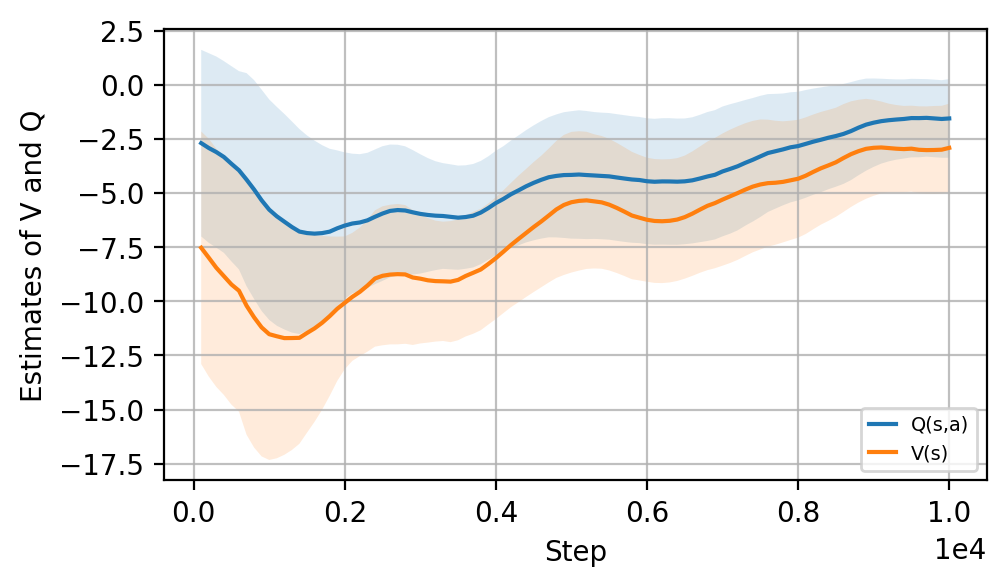

In [223]:
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
x_label = "Step"
y_label = "Estimates of V and Q"

key_name = "step"
value_name = "Q(s,a)"
# value_name = "maxQ"
curve_name = value_name

log_path = os.path.join(log_dir, "avg_meter.log")
save_path = os.path.join(parent_log_dir, "step-V-Q")

plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=False, smooth=10, max_key=True, save_path=False)
value_name = "V(s)"
curve_name = value_name
plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=True, smooth=10, max_key=True, save_path=False)

plt.legend(fontsize="x-small", markerscale=0.8, handlelength=1.4, loc="lower right", ncol=1)

if save_path:
    plt.savefig(f"{save_path}.png")

### Compare algos, estimated Q values

In [74]:
gamma = 0.95
def Q(K):
    return 5 * gamma ** K - sum(gamma ** np.arange(K))
print(Q(K=3))
print(Q(K=2))
print(Q(K=1))
print(Q(K=0))

(Q(0)+ Q(1)+ Q(2)+ Q(3)) / 4

1.4343749999999993
2.5625
3.75
5.0


np.float64(3.18671875)

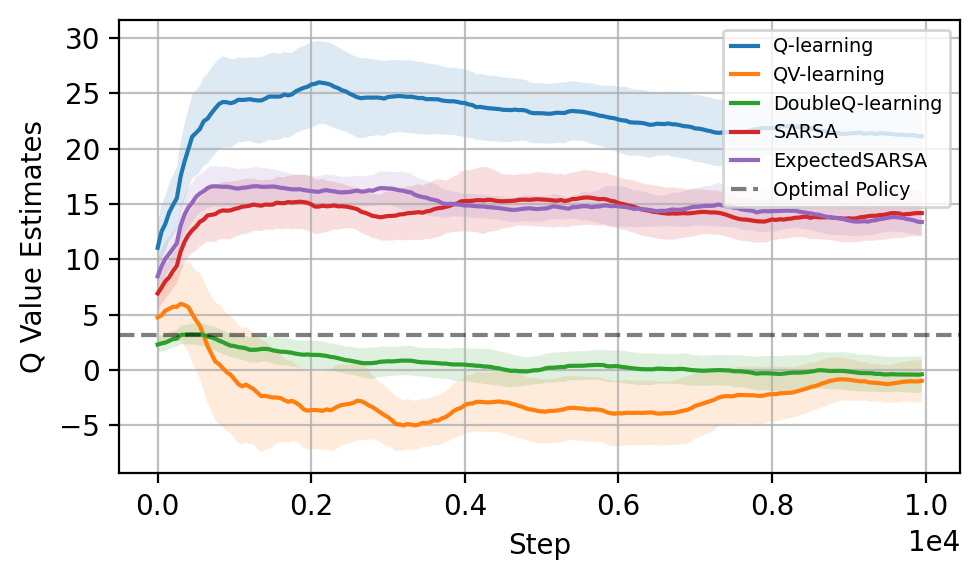

In [20]:


# file_name = "episodic.log"
# file_name = "avg_meter.log"
file_name = "eval.log"
# file_name = "true_return.log"

key_name = "step"
x_label = "Step"

# value_name = y_label = "reward"
# value_name = "reached_goal"
value_name = "avg_max_Q"
# value_name = "start_state_maxQ"

# y_label = "Prob reaching Goal#1"
y_label = "Q Value Estimates"

if y_label == "Q Value Estimates":
    for log_dir in log_dirs:
        if log_dir.split('/')[-1] == "VQ-learning":
            log_path_true_return = os.path.join(log_dir, "true_return.log") # better make sure the first algo is the one with true return
            # plot_avg_true_Q(log_path_true_return)

# plt.axhline(y=1.434, linestyle='--', color='black', label="Optimal")

# log_dirs = {}
# for algo, dir in zip(algos, dirs):
#     log_dirs[algo] = f"results/2rooms_rwd0.1(-0.1,1)/{algo}/{dir}"
for log_dir in log_dirs:
    log_path = os.path.join(log_dir, file_name)
    curve_name = log_dir.split('/')[-1]

    plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=True, smooth=10, max_key=True, save_path=False)

optimal_value = 3.1867 # for GridInDoubleQ
# optimal_value = 0.1 # for 2rooms_rwd0.1(-0.1,1)
plt.axhline(y=optimal_value, linestyle='--', color='black', alpha=0.5, label="Optimal Policy")
# plt.ylim(-0.1, 1.1)
plt.legend(
    fontsize='x-small',
    markerscale=0.8,
    handlelength=1.4,
    loc="upper right",
    ncol=1
    )

save_dir = parent_log_dir
save_path = os.path.join(parent_log_dir, f"step-{value_name}-acrossAlgos")
# create save_dir if not exists
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
if save_path:
    plt.savefig(f"{save_path}")


# log_dir = "results/2rooms_randinit0_eps0.3to0.0_decay0.9998_buffer1_1_is0.0_syncVQ0_repeat5_steps30000"
# key_name = "step"
# value_name = "reward"
# # value_name = "maxQ"
# x_label = key_name
# y_label = value_name
# label_name = algo_name
# log_path = os.path.join(log_dir, "episodic.log")
# print(log_path)
# save_path = os.path.join(log_dir, "step-reward.png")
# # log_path = os.path.join('results/2rooms_steps30000_alphaQ0.1', "episodic.log")
# plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=label_name, interpolate=True, smooth=10, max_key=True, save_path=False)


## Compare algos, any metrics

/Users/yuan/work/temp/DVQN_RL/gridworld/results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/Q-learning
/Users/yuan/work/temp/DVQN_RL/gridworld/results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/VQ-learning
/Users/yuan/work/temp/DVQN_RL/gridworld/results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/DoubleQ-learning
/Users/yuan/work/temp/DVQN_RL/gridworld/results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/SARSA
/Users/yuan/work/temp/DVQN_RL/gridworld/results/GridInDoubleQ/nA10_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat20_steps10000/ExpectedSARSA


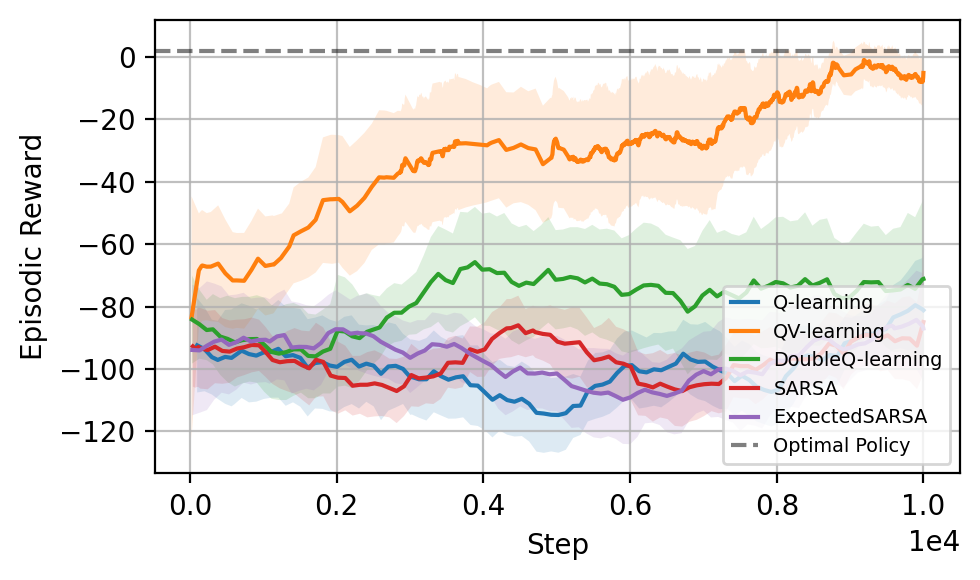

In [21]:
file_name = "episodic.log"

key_name = "step"
x_label = "Step"

value_name = "reward"
y_label = "Episodic Reward"
# value_name = "reached_goal"
# value_name = "reach_desired_goal"
# value_name = "avg_max_Q"

# y_label = "Prob reaching Goal#1"
# y_label = "Estimated Q Values"

for log_dir in log_dirs:
    print(log_dir)
    log_path = os.path.join(log_dir, file_name)
    curve_name = log_dir.split('/')[-1]
    plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=True, smooth=20, max_key=True, save_path=False)

# plt.plot(np.ones(num_of_episode) * constant["value"], '--', color='black', label=constant["label"])
plt.axhline(y=2, linestyle='--', color='black', alpha=0.5, label="Optimal Policy") #y=2 for GridInDoubleQ
# plt.ylim(-0.1, 1.1)
plt.legend(
    fontsize='x-small',
    markerscale=0.8,
    handlelength=1.4,
    loc="lower right",
    ncol=1
    )

save_dir = parent_log_dir
save_path = os.path.join(save_dir, f"step-{value_name}-acrossAlgos")
# create save_dir if not exists
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
if save_path:
    plt.savefig(f"{save_path}")

## Estimation Bias Evaluation

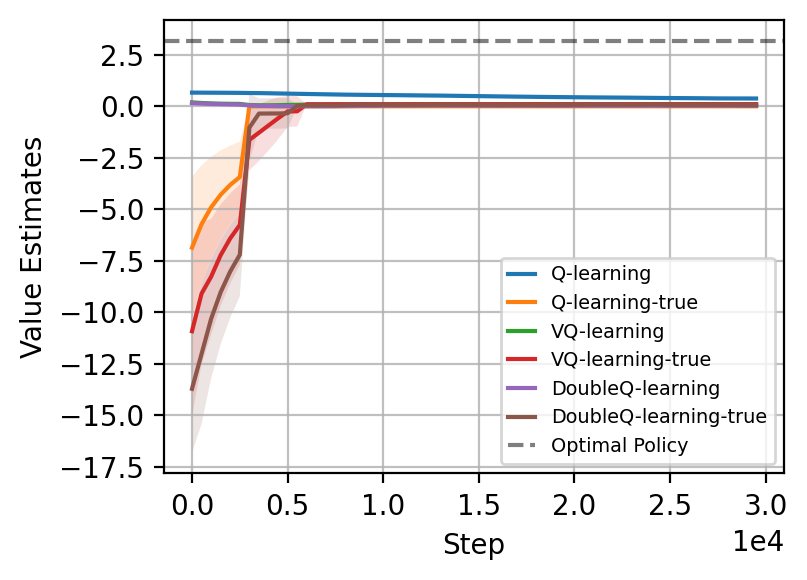

In [203]:
file_name = "eval.log"
# file_name = "true_return.log"

key_name = "step"
x_label = "Step"

# value_name = y_label = "reward"
# value_name = "reached_goal"
value_name = "avg_max_Q"
# value_name = "start_state_maxQ"

# y_label = "Prob reaching Goal#1"
y_label = "Value Estimates"


for log_dir in log_dirs:
    algo = log_dir.split("/")[-1]
    if algo in ["VQ-learning", "DoubleQ-learning", "Q-learning"]:
        log_path = os.path.join(log_dir, file_name)
        curve_name = log_dir.split("/")[-1]
        plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=True, smooth=10, max_key=True, save_path=False)
        plot_metric(log_path, key_name, "avg_return", x_label, y_label, label_name=curve_name+'-true', interpolate=True, smooth=10, max_key=True, save_path=False)

        # log_path_true_return = os.path.join(log_dir, "true_return.log")
        # mean_true_returns = []
        # with open(log_path_true_return) as f:
        #     for _, line in enumerate(f):
        #         # line is a list and compute and average value of the list
        #         data = json.loads(line)
        #         mean_true_returns.append(np.mean(data))
        # # true_returns = np.array(true_returns)
        # # true_returns = np.mean(true_returns, axis=0)
        # for line in plt.gca().get_lines():
        #     if line.get_label() == curve_name:
        #         line_color = line.get_color()

        # plt.axhline(y=np.mean(mean_true_returns), linestyle="-", color=line_color, alpha=0.5, label=f"{algo} True Value")

plt.axhline(y=3.1867, linestyle="--", color="black", alpha=0.5, label="Optimal Policy")
# plt.ylim(-0.1, 1.1)
plt.legend(fontsize="x-small", markerscale=0.8, handlelength=1.4, loc="best", ncol=1)

save_dir = os.path.join(log_dirs[0])
save_path = os.path.join(save_dir, f"step-evalEstimationBias-acrossAlgos")
# create save_dir if not exists
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
if save_path:
    plt.savefig(f"{save_path}")

## Compare algos, episode lengths

results/GridInDoubleQ/nA4_randinit0_Eps|count_based|_Alpha|count_based|_Buff1-1_noisyV0.0_repeat41_steps10000/Q-learning
results/GridInDoubleQ/nA4_randinit0_Eps|count_based|_Alpha|count_based|_Buff1-1_noisyV0.0_repeat41_steps10000/VQ-learning
results/GridInDoubleQ/nA4_randinit0_Eps|count_based|_Alpha|count_based|_Buff1-1_noisyV0.0_repeat41_steps10000/DoubleQ-learning
results/GridInDoubleQ/nA4_randinit0_Eps|count_based|_Alpha|count_based|_Buff1-1_noisyV0.0_repeat41_steps10000/SARSA
results/GridInDoubleQ/nA4_randinit0_Eps|count_based|_Alpha|count_based|_Buff1-1_noisyV0.0_repeat41_steps10000/ExpectedSARSA


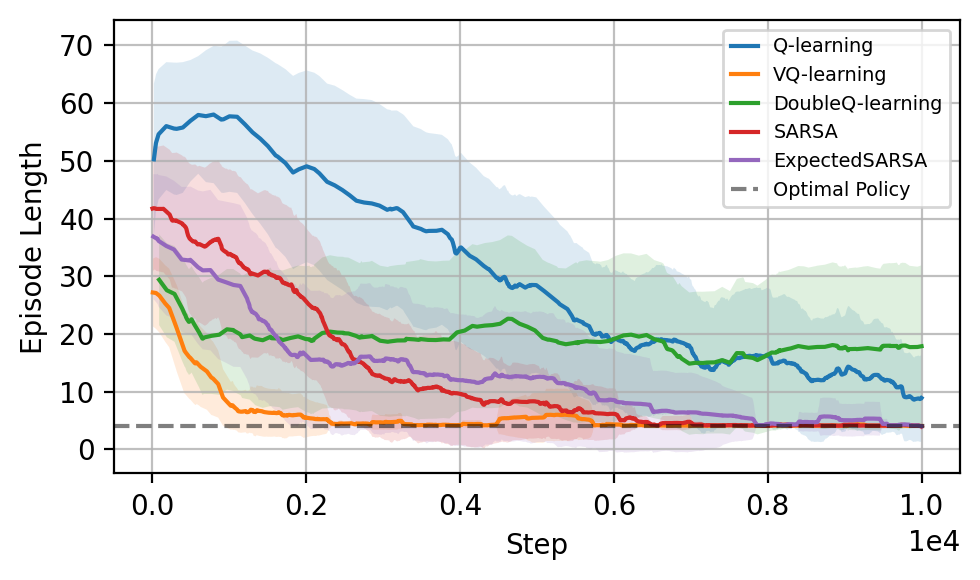

In [341]:
file_name = "episodic.log"

key_name = "step"
x_label = "Step"

value_name = "len_episode"
y_label = "Episode Length"
# value_name = "reached_goal"
# value_name = "reach_desired_goal"
# value_name = "avg_max_Q"

# y_label = "Prob reaching Goal#1"
# y_label = "Estimated Q Values"

for log_dir in log_dirs:
    print(log_dir)
    log_path = os.path.join(log_dir, file_name)
    curve_name = log_dir.split('/')[-1]
    plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=True, smooth=20, max_key=True, save_path=False)

plt.axhline(y=4, linestyle='--', color='black', alpha=0.5, label="Optimal Policy")
# plt.ylim(-0.1, 1.1)
plt.legend(
    fontsize='x-small',
    markerscale=0.8,
    handlelength=1.4,
    loc="upper right",
    ncol=1
    )

save_dir = parent_log_dir
save_path = os.path.join(save_dir, f"step-{value_name}-acrossAlgos")
# create save_dir if not exists
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
if save_path:
    plt.savefig(f"{save_path}")

## Compare algos, reached_goal

Figure saved to /Users/yuan/work/temp/DVQN_RL/gridworld/results/GridInDoubleQ/nA4_randinit0_Eps|count_based|_Alpha|count_based|_Buff500-1_noisyV0.0_repeat30_steps10000/Q-learning/step-reach_desired_goal-acrossAlgos


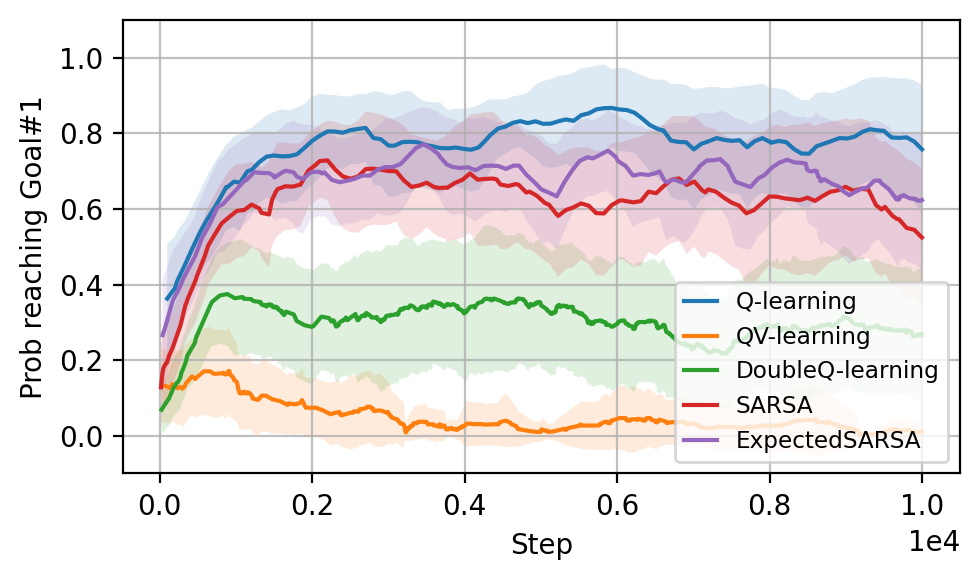

In [17]:
file_name = "episodic.log"

key_name = "step"
x_label = "Step"

# value_name = y_label = "reward"
# value_name = "reached_goal"
value_name = "reach_desired_goal"
# value_name = "avg_max_Q"

y_label = "Prob reaching Goal#1"
# y_label = "Estimated Q Values"

for log_dir in log_dirs:
    log_path = os.path.join(log_dir, file_name)
    curve_name = log_dir.split("/")[-1]
    plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=True, smooth=10, max_key=True, save_path=False)

plt.ylim(-0.1, 1.1)
plt.legend(fontsize="small", markerscale=0.8, handlelength=1.4, loc="lower right", ncol=1)

save_dir = os.path.join(log_dirs[0])
save_path = os.path.join(save_dir, f"step-{value_name}-acrossAlgos")
# create save_dir if not exists
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
if save_path:
    plt.savefig(f"{save_path}")
    print(f"Figure saved to {save_path}")

## Plot Episodic Reward for one method specified by log_dir

In [ ]:
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
key_name = "step"
value_name = "reward"
# value_name = "maxQ"
# value_name = "reached_goal"
# value_name = "len_episode"
x_label = key_name
y_label = value_name
label_name = algo_name
log_path = os.path.join(log_dir, "episodic.log")
save_path = os.path.join(log_dir, f"step-{value_name}")
# log_path = os.path.join('results/2rooms_steps30000_alphaQ0.1', "episodic.log")
plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=label_name, interpolate=True, smooth=10, max_key=True, save_path=save_path)

# key_name = "step"
# # value_name = "maxQ"
# value_name = "reward"
# label_name = "VQ-learning1.0"
# log_path = os.path.join('results/2rooms_steps100000_raninit1_alphaV0.1_alphaQ1.0_eps0.3to0.00_decay0.9998_repeat10', "episodic.log")
# plot_metric(log_path, key_name, value_name, label_name=label_name, interpolate=True, smooth=10, max_key=True)

### Plot one metric for one method specified by log_dir

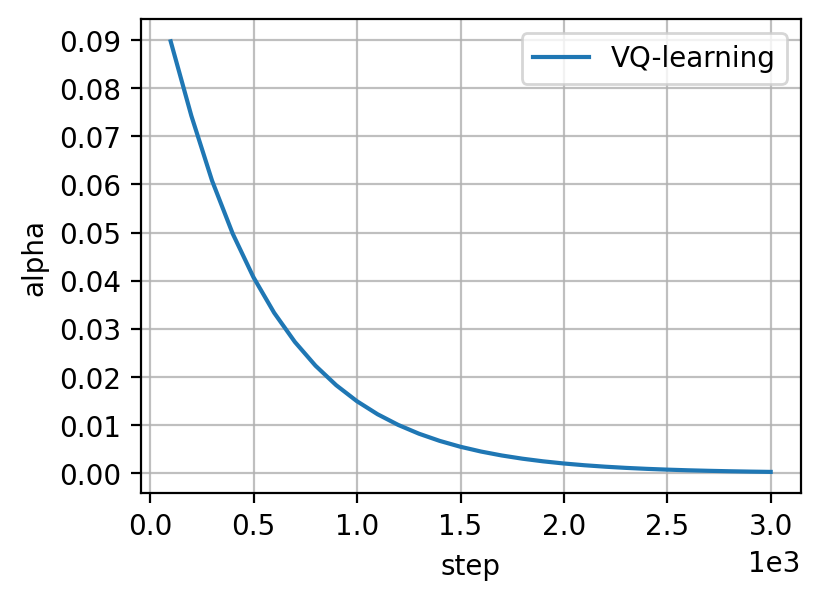

In [41]:
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
key_name = "step"
# value_name = "Q(s,a)"
# value_name = "maxQ"
# value_name = "eps"
value_name = "alpha"
# value_name = "temperature"
smooth = 1
x_label = key_name
y_label = value_name
label_name = algo_name
# log_path = os.path.join(log_dir, "episodic.log")
log_path = os.path.join(log_dir, "avg_meter.log")
save_path = os.path.join(log_dir, f"step-{value_name}.png")

plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=label_name, interpolate=True, smooth=smooth, max_key=True, save_path=save_path)

### Plot estimated Q and the actual True Return of the method

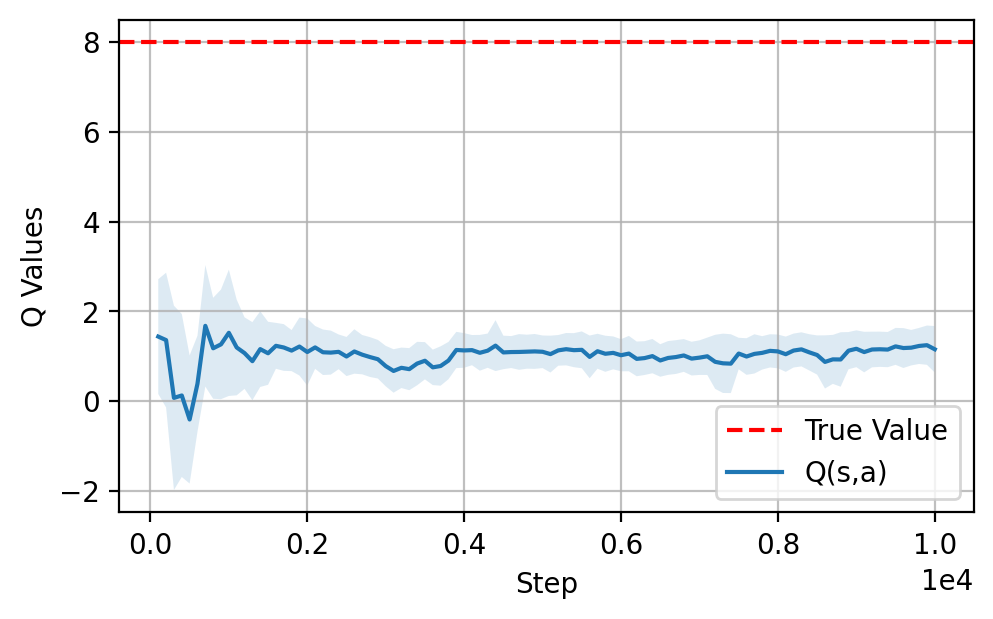

In [193]:
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
x_label = "Step"
y_label = 'Q Values'

key_name = "step"
value_name = "Q(s,a)"
# value_name = "maxQ"
# value_name = "avg_max_Q"
curve_name = value_name

log_path_true_return = os.path.join(log_dir, "true_return.log")
plot_avg_true_Q(log_path_true_return)

log_path = os.path.join(log_dir, "avg_meter.log")
save_path = os.path.join(log_dir, "step-Q-TrueQ")

plot_metric(log_path, key_name, value_name, x_label, y_label, label_name=curve_name, interpolate=False, smooth=1, max_key=True, save_path=False)



### Plot all runs for VQ-learning

In [ ]:
# log_dir = "results/2rooms_steps100000_raninit1_alphaV0.1_alphaQ1.0_eps0.3to0.00_decay0.9998_repeat10"
# log_dir = "results/2rooms_rwd0.1/VQ-learning/randinit1_eps0.5to0.0_decay0.99995_buffer1_1_is0.0_syncVQ0_repeat20_steps200000"
# log_path = os.path.join(log_dir, "avg_meter.log")
algo_name = "VQ-learning"
log_dir = log_dirs[algo_names.index(algo_name)]
log_path = os.path.join(log_dir, "episodic.log")
x_label = "step"
# y_label = "reward"
# y_label = "maxQ"
y_label = "reached_goal"
# y_label = "len_episode"


save_path = os.path.join(log_dir, f"step-{y_label}-allruns")

smooth = 100

last_idice = []
with open(log_path, "r") as f:
    last_repeat_idx = 0
    for line_idx, line in enumerate(f):
        data = json.loads(line)
        if data["repeat_idx"] != last_repeat_idx:
            last_idice.append(line_idx - 1)
            last_repeat_idx = data["repeat_idx"]

if line_idx != last_idice[-1]:
    last_idice.append(line_idx)
last_idice = np.array(last_idice)
# for i in range(n_repeat):
#     # count number of lines for repeat i
#     n_lines = 0
#     with open(log_path, "r") as f:
#         for line in f:
#             data = json.loads(line)
#             if data["repeat_idx"] == i:
#                 n_lines += 1
#     last_idice.append(n_lines)
# last_idice = np.array(last_idice)
# # each element is the sum of the previous elements
# last_idice = np.cumsum(last_idice)
# last_idice = last_idice - 1

keys = []
values = []

with open(log_path, "r") as f:
    for i, line in enumerate(f):
        data = json.loads(line)
        if x_label in data and y_label in data:
            keys.append(data[x_label])
            values.append(data[y_label])
        if i in last_idice:
            keys, values = np.array(keys), np.array(values)
            print(len(keys), keys[-1])
            if smooth > 1 and values.shape[0] > 0:
                K = np.ones(smooth)
                ones = np.ones(values.shape[0])
                values = np.convolve(values, K, "same") / np.convolve(ones, K, "same")
            # plot data
            plt.plot(keys, values, label=f"rep_idx: {np.where(last_idice == i)[0][0]}")

            keys = []
            values = []


plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["figure.dpi"] = 200
plt.rcParams["font.size"] = 10
plt.grid(alpha=0.8)
# plt.ylim(top=2.0)
# plt.legend(ncol=1)
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
# save the plot to save_path
plt.savefig(f"{save_path}.png")
# plt.close()